# Klein VAE Experiments

In [25]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from src.data.uniform_filters_datamodule import UniformFiltersDataModule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE, ConvolutionalVAE

import matplotlib.pyplot as plt

from lightning.pytorch.trainer import Trainer

import random
import numpy as np

from ripser import ripser
from persim import plot_diagrams


In [32]:
BATCH_SIZE = 512

Total training examples: 32000


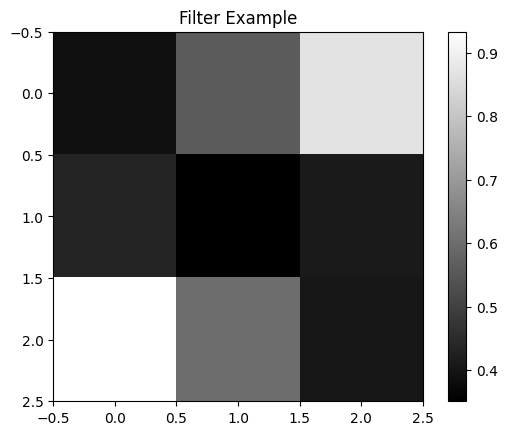

In [33]:
datamodule = UniformFiltersDataModule(num_samples_per_angle=200, batch_size=BATCH_SIZE)
datamodule.setup()
filter_example = datamodule.train_dataloader().dataset[0][0].reshape(3,3)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

### Testing that samples from `UniformFiltersDataModule` lie on the Klein bottle

In [28]:
dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

In [29]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_21878/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_21878/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


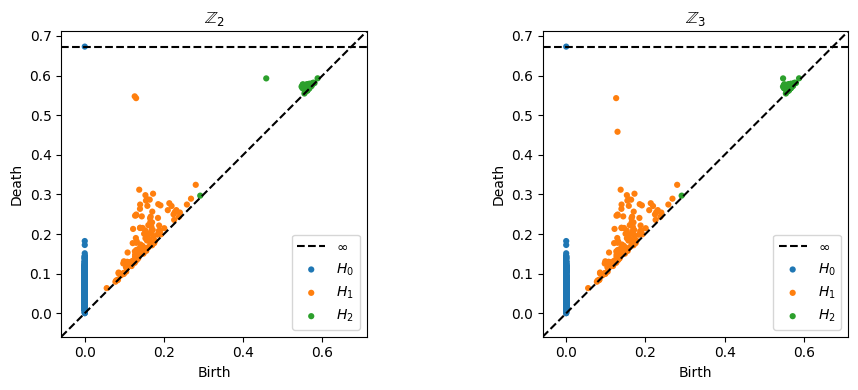

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Running the model

In [37]:
vae_model = SimpleVAE(hidden_dims=[16,32,16])
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=BATCH_SIZE, lr=1e-4, kl_weight=1e-1)

#### Checking the filters BEFORE training

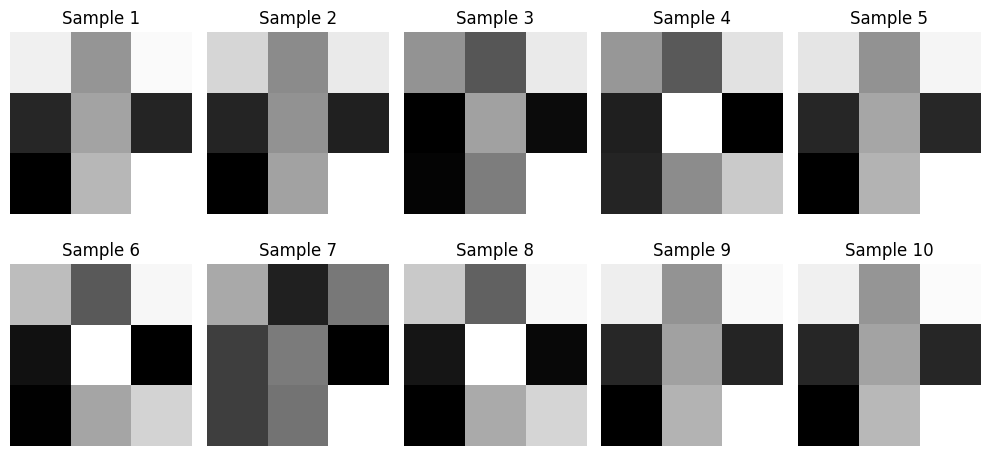

In [13]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

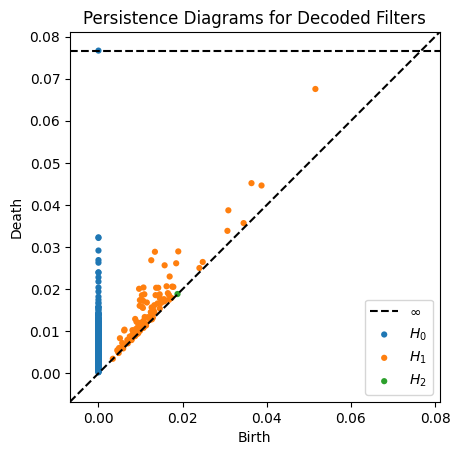

In [14]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Decoded Filters')

### Training

In [38]:
trainer = Trainer(accelerator="cpu", max_epochs=100, enable_progress_bar=True)
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 2.6 K  | train
--------------------------------------------
2.6 K     Trainable params
0         Non-trainable params
2.6 K     Total params
0.010     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 63/63 [00:00<00:00, 217.28it/s, v_num=26]        

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 63/63 [00:00<00:00, 214.56it/s, v_num=26]


In [39]:
# Retrieve and display the logged metrics after training
metrics = trainer.callback_metrics
print(metrics)

{'train_loss': tensor(1542.4082), 'recon_loss': tensor(1541.1973), 'kl_div': tensor(12.1094), 'val_loss': tensor(3040.1851), 'val_recon_loss': tensor(3039.0920), 'val_kl_div': tensor(10.9260)}


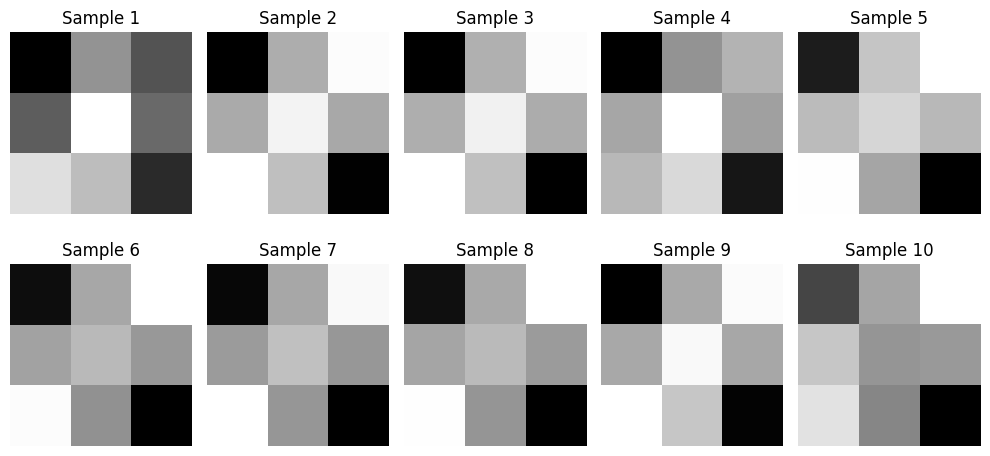

In [42]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

### Testing that decoded samples also lie on the Klein bottle

In [44]:
samples = klein_vae_module.sample(num_samples=1000)
decoded = klein_vae_module.model.decode(samples)
batch = decoded.detach().cpu().numpy()

In [45]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_21878/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_21878/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


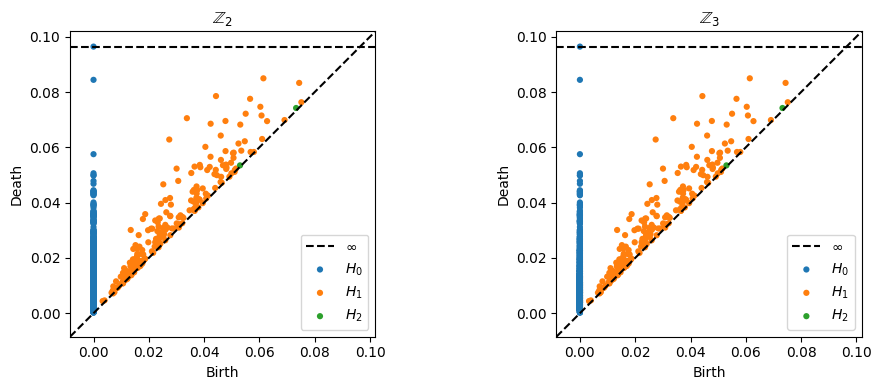

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()